## Импорт файлаб библиотек и настройки 

In [1]:
import pandas as pd

df = pd.read_csv("hh_vacancies_clean.csv")
print(f"Загружено: {len(df)} вакансий")

Загружено: 5573 вакансий


## EDA

In [2]:
df.shape

(5573, 15)

In [3]:
df.dtypes # просмотр типа файдов

query               object
id                   int64
name                object
employer            object
area                object
salary_from        float64
salary_to          float64
currency            object
experience          object
work_format         object
is_remote             bool
employment_form     object
url                 object
published_at        object
salary_avg         float64
dtype: object

In [4]:
df.head(10) # просмотр таблицы, первых 10 строк 

,query,id,name,employer,area,salary_from,salary_to,currency,experience,work_format,is_remote,employment_form,url,published_at,salary_avg
0,аналитик данных,133222123,Аналитик данных,КАША.РУ,Москва,NaN,NaN,NaN,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133222123,2026-06-05 19:25:17+03:00,NaN
1,аналитик данных,133013965,Аналитик данных,Трикотаж Натали,Иваново (Ивановская область),50000.0,70000.0,RUR,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133013965,2026-06-05 19:10:43+03:00,60000.0
2,аналитик данных,133785898,Аналитик данных,Колл-Тулз,Москва,NaN,NaN,NaN,От 3 до 6 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133785898,2026-06-05 17:51:08+03:00,NaN
3,аналитик данных,133917742,Аналитик данных,Правительство Москвы,Москва,NaN,NaN,NaN,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133917742,2026-06-05 17:27:29+03:00,NaN
4,аналитик данных,132855212,Аналитик данных,Медиалогия,Москва,NaN,NaN,NaN,От 3 до 6 лет,"Удалённо, Гибрид",True,Полная,https://hh.ru/vacancy/132855212,2026-06-05 17:17:33+03:00,NaN
5,аналитик данных,133569397,Аналитик данных,Руссиатэкс,Москва,140000.0,NaN,RUR,От 1 года до 3 лет,"На месте работодателя, Гибрид",False,Полная,https://hh.ru/vacancy/133569397,2026-06-05 16:31:00+03:00,140000.0
6,аналитик данных,133912768,Аналитик данных,Правительство Москвы,Москва,NaN,NaN,NaN,От 1 года до 3 лет,Гибрид,False,Полная,https://hh.ru/vacancy/133912768,2026-06-05 15:43:55+03:00,NaN
7,аналитик данных,133777412,Аналитик данных,СиМП Телеком,Москва,90000.0,NaN,RUR,Нет опыта,На месте работодателя,False,Полная,https://hh.ru/vacancy/133777412,2026-06-05 15:25:56+03:00,90000.0
8,аналитик данных,133910687,Аналитик данных,Медиа Бизнес Солюшенс,Москва,NaN,NaN,NaN,От 1 года до 3 лет,"Удалённо, Гибрид",True,Полная,https://hh.ru/vacancy/133910687,2026-06-05 15:05:33+03:00,NaN
9,аналитик данных,133910390,Аналитик данных,«UZUM TECHNOLOGIES»,Москва,NaN,NaN,NaN,От 3 до 6 лет,Удалённо,True,Полная,https://hh.ru/vacancy/133910390,2026-06-05 15:01:00+03:00,NaN


In [5]:
df.isnull().sum() # просмотр нулевых значений, пропусков

query                 0
id                    0
name                  0
employer              0
area                  0
salary_from        3842
salary_to          4474
currency           3633
experience            0
work_format          91
is_remote             0
employment_form       0
url                   0
published_at          0
salary_avg         3633
dtype: int64

#### Insight 
* 4474 раза — не определены пределы заработной платы
* 3842 раза — минимальный порог зарплаты
* 3633 раза — не указана страна (территориальное расположение)
* 3633 раза — средняя зарплата в этой категории

In [6]:
df.describe()

,id,salary_from,salary_to,salary_avg
count,5.573000e+03,1731.000000,1099.000000,1940.000000
mean,1.329726e+08,132963.652224,176228.512284,149619.020103
std,2.169026e+06,82385.838671,102635.118908,88327.860836
min,7.982028e+07,80.000000,200.000000,140.000000
25%,1.329251e+08,80000.000000,100000.000000,87777.500000
50%,1.333497e+08,114000.000000,150000.000000,130000.000000
75%,1.337543e+08,160000.000000,250000.000000,200000.000000
max,1.339252e+08,700000.000000,800000.000000,725000.000000


In [7]:
df.columns

Index(['query', 'id', 'name', 'employer', 'area', 'salary_from', 'salary_to',
       'currency', 'experience', 'work_format', 'is_remote', 'employment_form',
       'url', 'published_at', 'salary_avg'],
      dtype='object')

In [8]:
df = df.rename(columns={
    'query': 'category',
    'area': 'city',
    'name': 'sub-category'
})
df

,category,id,sub-category,employer,city,salary_from,salary_to,currency,experience,work_format,is_remote,employment_form,url,published_at,salary_avg
0,аналитик данных,133222123,Аналитик данных,КАША.РУ,Москва,NaN,NaN,NaN,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133222123,2026-06-05 19:25:17+03:00,NaN
1,аналитик данных,133013965,Аналитик данных,Трикотаж Натали,Иваново (Ивановская область),50000.0,70000.0,RUR,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133013965,2026-06-05 19:10:43+03:00,60000.0
2,аналитик данных,133785898,Аналитик данных,Колл-Тулз,Москва,NaN,NaN,NaN,От 3 до 6 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133785898,2026-06-05 17:51:08+03:00,NaN
3,аналитик данных,133917742,Аналитик данных,Правительство Москвы,Москва,NaN,NaN,NaN,От 1 года до 3 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133917742,2026-06-05 17:27:29+03:00,NaN
4,аналитик данных,132855212,Аналитик данных,Медиалогия,Москва,NaN,NaN,NaN,От 3 до 6 лет,"Удалённо, Гибрид",True,Полная,https://hh.ru/vacancy/132855212,2026-06-05 17:17:33+03:00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5568,бизнес аналитик,133908880,"Директор CIB (транспорт, инфраструктура, телеком)",Совкомбанк,Москва,NaN,NaN,NaN,От 3 до 6 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133908880,2026-06-05 14:31:29+03:00,NaN
5569,бизнес аналитик,133914386,Head of Performance/CMO,HumanCode,Москва,NaN,NaN,NaN,От 3 до 6 лет,Удалённо,True,Полная,https://hh.ru/vacancy/133914386,2026-06-05 16:14:06+03:00,NaN
5570,бизнес аналитик,133553836,Руководитель отдела маркетинга / Head of Marke...,КонсалтсСити,Москва,250000.0,NaN,RUR,От 3 до 6 лет,На месте работодателя,False,Полная,https://hh.ru/vacancy/133553836,2026-06-05 12:00:09+03:00,250000.0
5571,бизнес аналитик,133369139,Ассистент отдела маркетинга / Маркетинг-ассистент,Медицинский центр Альбатрос,Санкт-Петербург,53000.0,70000.0,RUR,От 1 года до 3 лет,Гибрид,False,Частичная,https://hh.ru/vacancy/133369139,2026-06-05 17:15:15+03:00,61500.0


### What is the demand split by job category? — Каково соотношение спроса по направлениям (BI, Data, Business Analyst)?

In [9]:
metrics_by_category = (
    df.groupby('category')['id']
        .count()
        .sort_values(ascending=False ) 
        .reset_index(name ='count')
)
metrics_by_category['percent'] = (
    metrics_by_category['count']
    / metrics_by_category['count'].sum()
    *100
).round(2)

metrics_by_category


,category,count,percent
0,аналитик данных,1992,35.74
1,data analyst,1332,23.90
2,BI аналитик,1273,22.84
3,бизнес аналитик,976,17.51


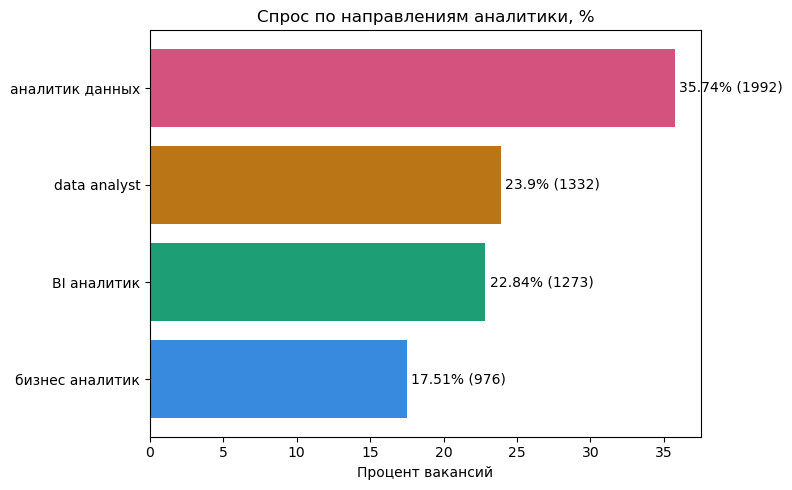

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    metrics_by_category['category'][::-1],
    metrics_by_category['percent'][::-1],
    color=['#378ADD', '#1D9E75', '#BA7517', '#D4537E']
)
ax.set_title('Спрос по направлениям аналитики, %')
ax.set_xlabel('Процент вакансий')
for i, (val, pct) in enumerate(zip(
    metrics_by_category['count'][::-1],
    metrics_by_category['percent'][::-1]
)):
    ax.text(pct + 0.3, i, f'{pct}% ({val})', va='center')
plt.tight_layout()
plt.savefig('category_demand.png', dpi=150)
plt.show()

### Which category offers the highest salaries? — Какое направление платит больше всего?